In [1]:
import nest
import os
import network
import addons
import helpers
import matplotlib.pyplot as plt
import numpy as np
from network_params import net_dict
import network_params
from sim_params import sim_dict
from stimulus_params import stim_dict


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:14

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning:Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.


In [2]:
from scipy.sparse import dok_matrix 
from scipy.fft import fft
from scipy.fft import fftfreq
from scipy import signal
from scipy.signal import butter, lfilter
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.interpolate import pchip
from scipy.interpolate import make_smoothing_spline

def compute_FFT(signal_data,freq_sample= 0.001):
    analysis_interval_start = (addons.analysis_dict["analysis_start"] -500) /0.2
    analysis_interval_end = (addons.analysis_dict["analysis_end"] -500)/ 0.2
    analysis_interval_start = int(analysis_interval_start)
    analysis_interval_end = int(analysis_interval_end)
    FFT_Results = {}

    for i in range(len(signal_data)):
        FFT_Results[i] = fft(signal_data[i][analysis_interval_start:analysis_interval_end]-np.mean(signal_data[i][analysis_interval_start:analysis_interval_end]))

    #Calcular los valores de frequencia correspondientes
    freq = fftfreq(len(signal_data[i][analysis_interval_start:analysis_interval_end]),d=freq_sample)

    indx = int(len(signal_data[i][analysis_interval_start:analysis_interval_end])/2)
    result_fourier = {}

    for i in FFT_Results:
        result_fourier[i] = np.abs(FFT_Results[i])[:indx]
    results_freq = freq[:indx]



    return result_fourier, results_freq, indx

In [3]:
from scipy.stats import entropy as scipy_entropy

def compute_spectral_entropy(result_fourier, results_freq, f_max=150.0):
    """
    Spectral entropy of the normalised power spectrum, restricted to [0, f_max] Hz.

    Restricting the band matters: computed over the full spectrum (up to Nyquist,
    here ~2500 Hz), entropy is dominated by thousands of high-frequency bins that
    no real population-rate signal populates, and a white-noise (shot-noise) null
    saturates near log2(n_bins) regardless of rate -- which makes the metric
    insensitive to real spectral differences and unable to show the rate-dependent
    confound it's meant to control for. Restricting to [0, f_max] keeps the
    comparison in the physiologically relevant range (f_max=150 Hz comfortably
    covers the 80 Hz fundamental and its 40 Hz subharmonic).

    H = -sum(P * log(P))  where P is the normalised power (sums to 1) within
    [0, f_max] Hz.
    """
    mask = results_freq <= f_max
    spectral_entropy = {}
    for i in result_fourier:
        power      = result_fourier[i][mask] ** 2       # amplitude → power, band-limited
        total      = power.sum()
        if total == 0 or not np.isfinite(total):
            spectral_entropy[i] = np.nan                 # degenerate spectrum -- flag, don't silently zero
            continue
        power_norm = power / total                       # normalise to sum=1 (probability dist)
        spectral_entropy[i] = scipy_entropy(power_norm, base=2)   # bits
    return spectral_entropy


def compute_Q_factor(result_fourier, results_freq, target_freq=80.0, freq_window=20.0):
    """
    Q-factor = peak height / bandwidth (−3 dB bandwidth around target_freq).
    target_freq : Hz — centre of search window
    freq_window : Hz — ± search radius around target_freq
    """
    Q_factors    = {}
    peak_freqs   = {}
    peak_heights = {}
    bandwidths   = {}

    for i in result_fourier:
        power = result_fourier[i] ** 2

        # ── find the dominant peak near target_freq ───────────────────────────
        mask          = (results_freq >= target_freq - freq_window) & \
                        (results_freq <= target_freq + freq_window)
        freq_window_  = results_freq[mask]
        power_window  = power[mask]

        if len(power_window) == 0 or power_window.max() == 0:
            Q_factors[i] = np.nan
            peak_freqs[i] = np.nan
            peak_heights[i] = np.nan
            bandwidths[i] = np.nan
            continue

        peak_idx_local = np.argmax(power_window)
        peak_freq      = freq_window_[peak_idx_local]
        peak_height    = power_window[peak_idx_local]

        # ── −3 dB bandwidth ───────────────────────────────────────────────────
        half_power     = peak_height / 2.0          # −3 dB in linear power
        above_half     = power_window >= half_power

        # find left and right edges of the −3 dB region
        transitions    = np.diff(above_half.astype(int))
        rise_idxs      = np.where(transitions ==  1)[0]   # crossing upward
        fall_idxs      = np.where(transitions == -1)[0]   # crossing downward

        # pick the edges closest to the peak
        left_freq  = freq_window_[rise_idxs[rise_idxs  < peak_idx_local][-1]] \
                     if len(rise_idxs[rise_idxs  < peak_idx_local]) > 0 \
                     else freq_window_[0]
        right_freq = freq_window_[fall_idxs[fall_idxs > peak_idx_local][0] + 1] \
                     if len(fall_idxs[fall_idxs > peak_idx_local]) > 0 \
                     else freq_window_[-1]

        bw = right_freq - left_freq

        Q_factors[i]    = peak_freq / bw  if bw > 0 else np.nan
        peak_freqs[i]   = peak_freq
        peak_heights[i] = peak_height
        bandwidths[i]   = bw

    return Q_factors, peak_freqs, peak_heights, bandwidths


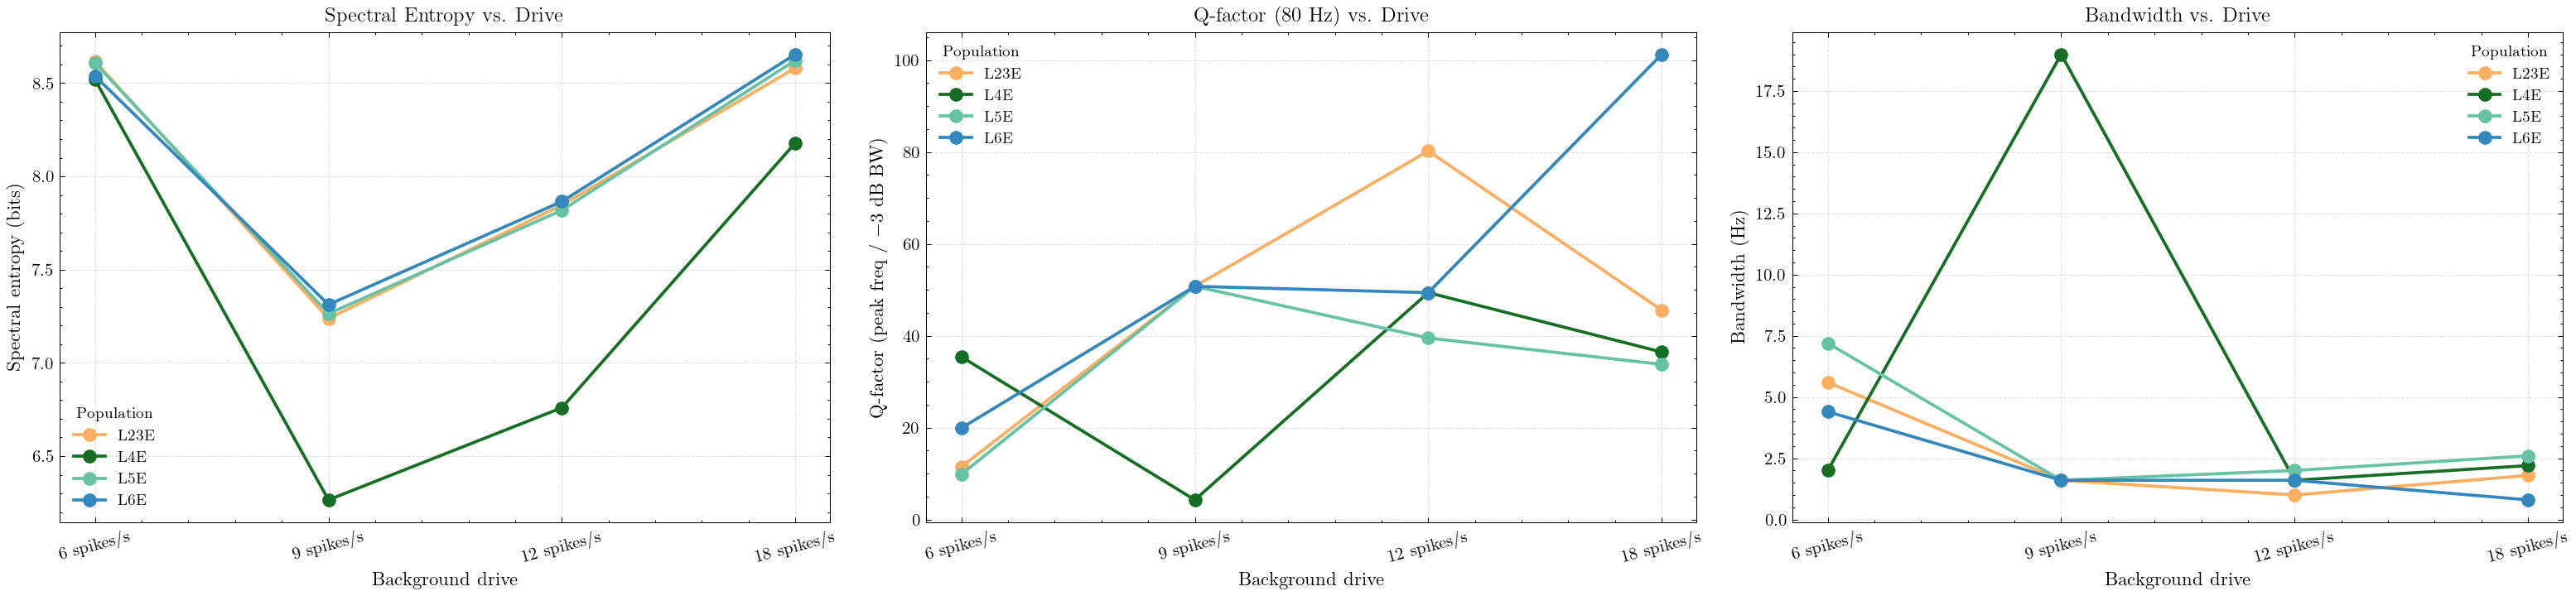

In [4]:
dirs = os.listdir("data_background_rate_fig_1")
dirs = sorted(dirs)

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
names       = [6, 9, 12, 18]
freq_sample = 0.0002

pops     = ["L23E", "L4E", "L5E", "L6E"]
n_pops   = len(pops)
n_drives = len(dirs)

all_entropy = {}
all_Q       = {}
all_bw      = {}

for i in range(n_drives):
    # ── load population activity for this drive ───────────────────────────
    base = "data_background_rate_fig_1/" + dirs[i] + "/trial_0/"
    pop_activity_i = []
    for j in range(n_pops):
        fpath = base + "measurements/pop_activities/pop_activity_" + str(j * 2) + ".dat"
        pop_activity_i.append(np.loadtxt(fpath))
    pop_activity_i = np.array(pop_activity_i)   # shape: (n_pops, n_timepoints)

    # ── FFT + metrics ─────────────────────────────────────────────────────
    a, b, c = compute_FFT(pop_activity_i, freq_sample=freq_sample)

    all_entropy[i]             = compute_spectral_entropy(a, b)
    all_Q[i], _, _, all_bw[i] = compute_Q_factor(a, b, target_freq=80.0, freq_window=20.0)

# ── Reshape into (n_pops × n_drives) arrays ──────────────────────────────────
entropy_arr = np.array([[all_entropy[d][p] for d in range(n_drives)] for p in range(n_pops)])
Q_arr       = np.array([[all_Q[d][p]       for d in range(n_drives)] for p in range(n_pops)])
bw_arr      = np.array([[all_bw[d][p]      for d in range(n_drives)] for p in range(n_pops)])


x           = np.arange(n_drives)
markers     = ['o', 'o', 'o', 'o']
colors_pops = ['#fdae61', "#166d24", '#66c2a5', '#3288bd']

fig, axes = plt.subplots(1, 3, figsize=(21, 5), dpi=150)

for pop_idx in range(n_pops):
    axes[0].plot(x, entropy_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])
    axes[1].plot(x, Q_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])
    axes[2].plot(x, bw_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])

for ax, title, ylabel in zip(
    axes,
    ["Spectral Entropy vs. Drive", "Q-factor (80 Hz) vs. Drive", "Bandwidth vs. Drive"],
    ["Spectral entropy (bits)", "Q-factor (peak freq / −3 dB BW)", "Bandwidth (Hz)"]
):
    ax.set_xticks(x)
    ax.set_xticklabels(labels_rate, rotation=15)
    ax.set_xlabel("Background drive", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(title="Population", fontsize=9, title_fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

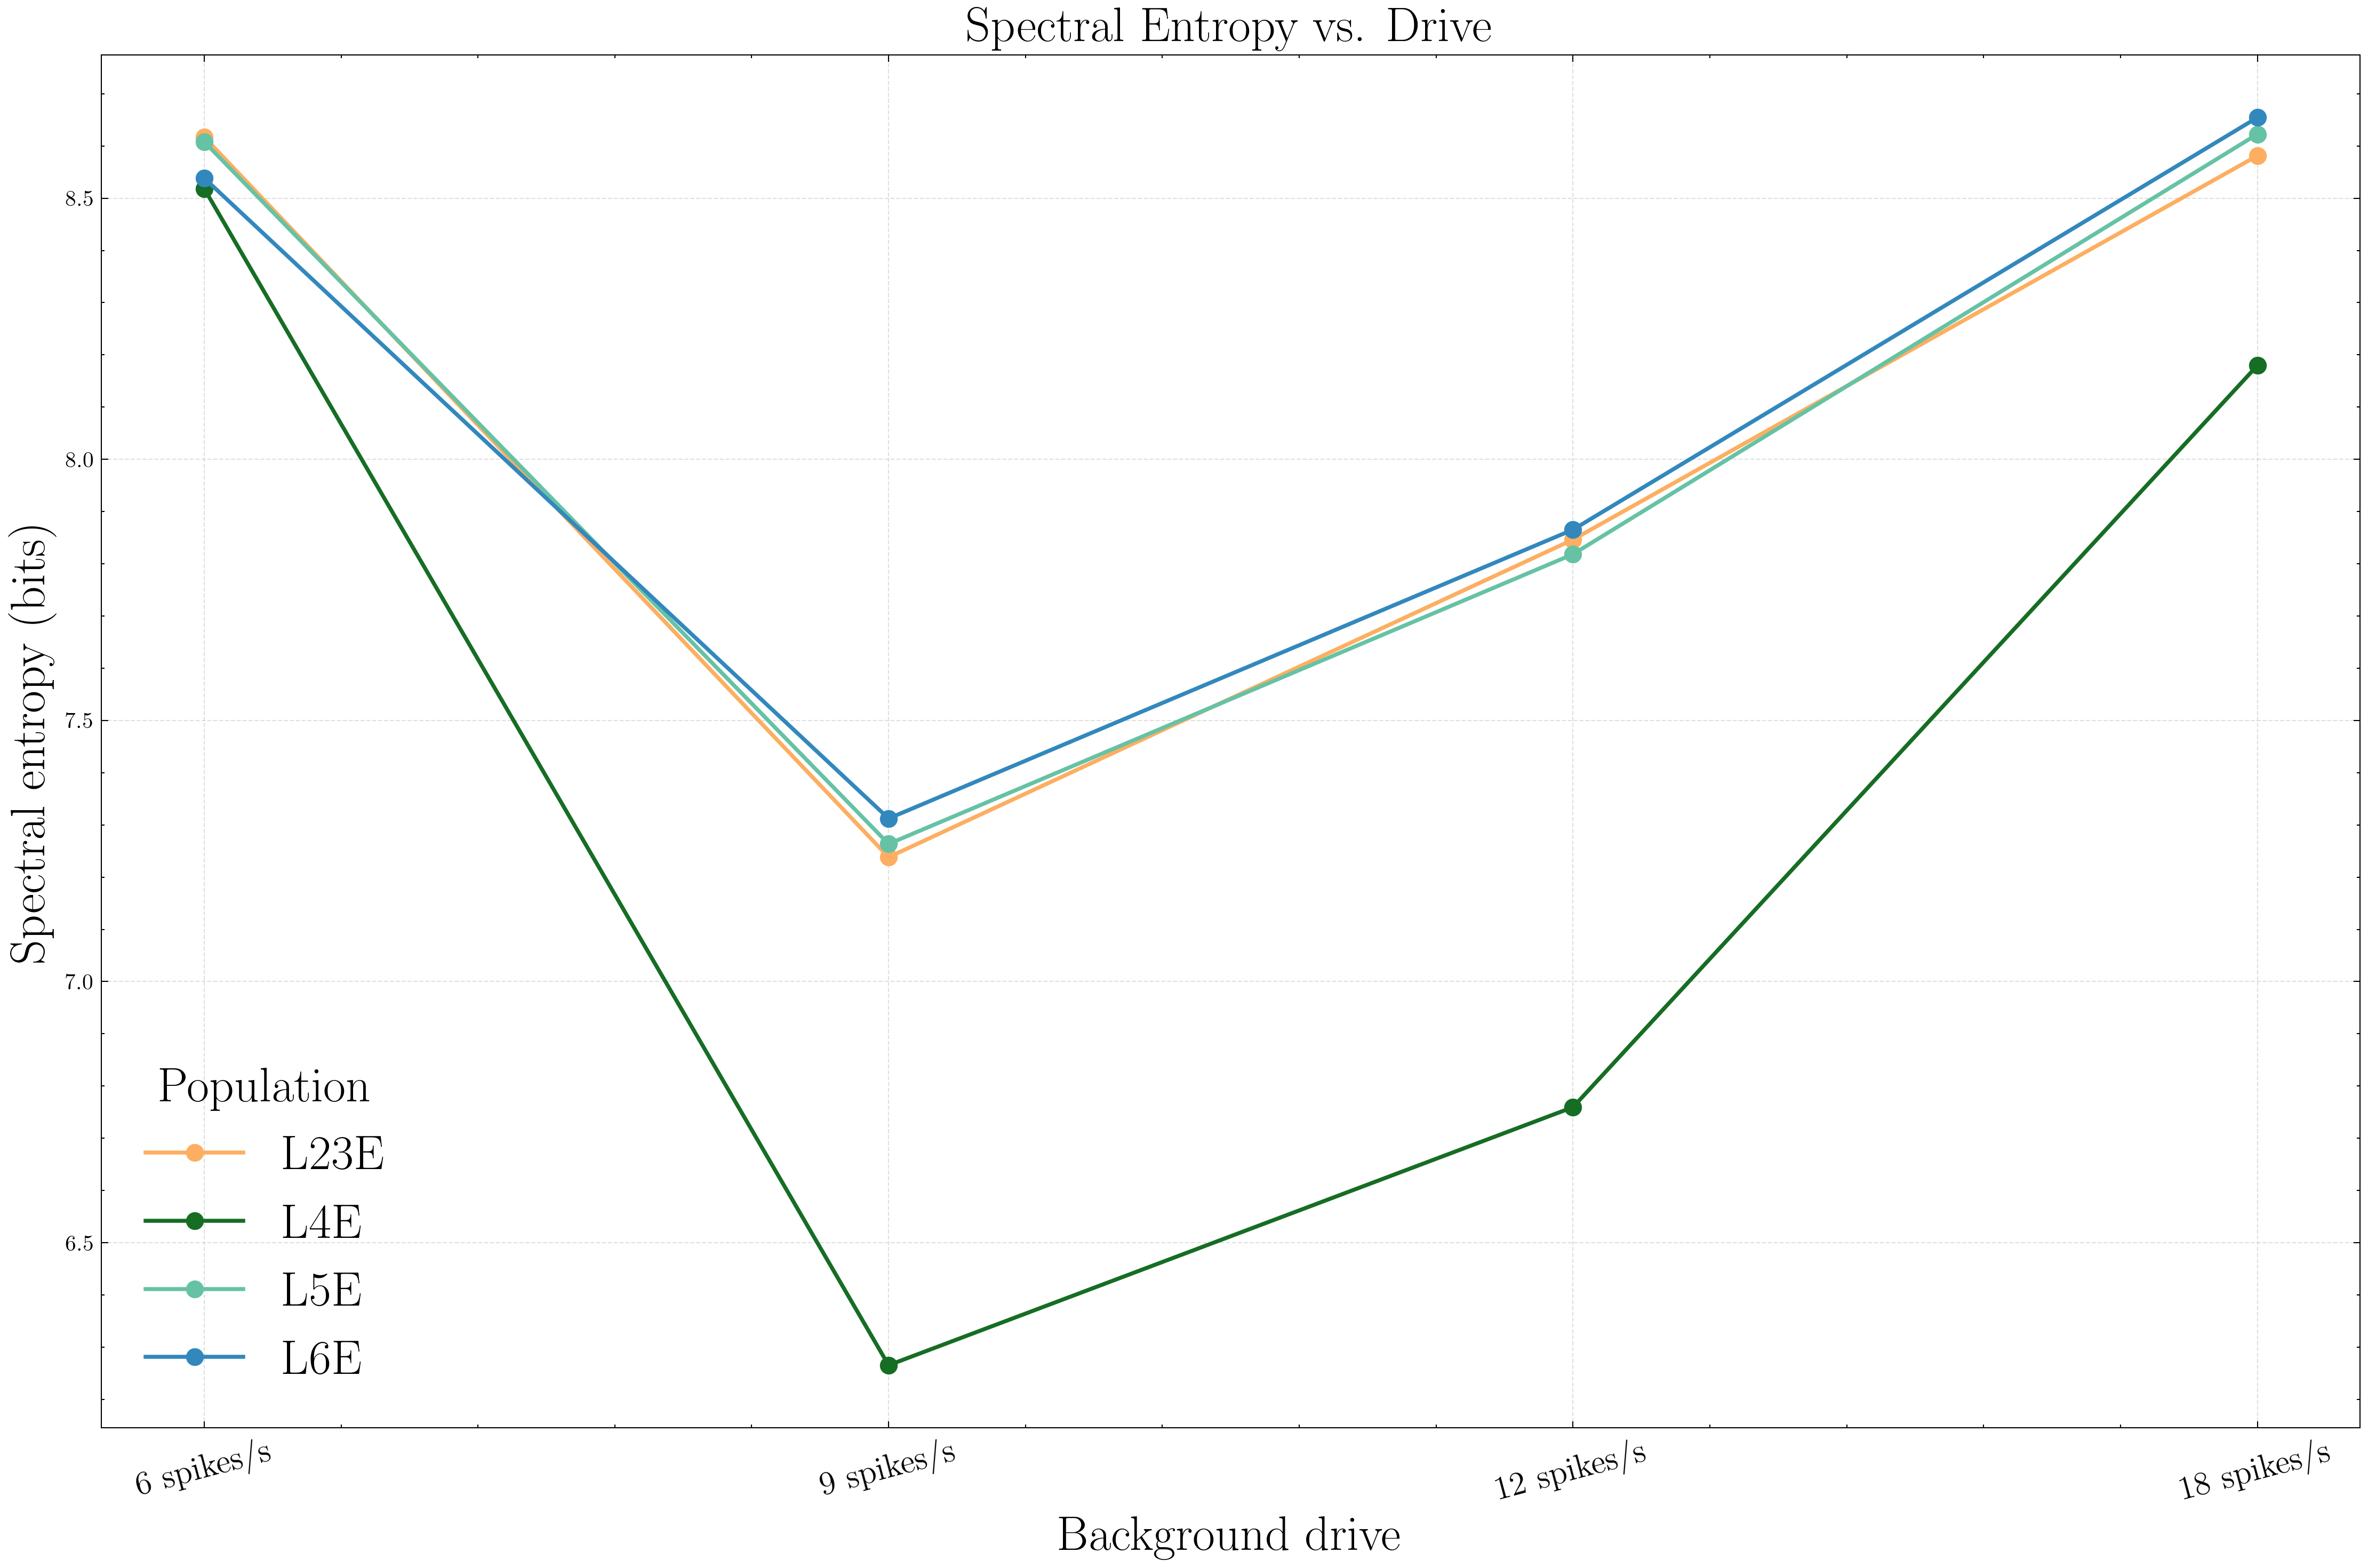

In [5]:
dirs = os.listdir("data_background_rate_fig_1")
dirs = sorted(dirs)

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
names       = [6, 9, 12, 18]
freq_sample = 0.0002

pops     = ["L23E", "L4E", "L5E", "L6E"]
n_pops   = len(pops)
n_drives = len(dirs)

all_entropy = {}
all_Q       = {}
all_bw      = {}

for i in range(n_drives):
    # ── load population activity for this drive ───────────────────────────
    base = "data_background_rate_fig_1/" + dirs[i] + "/trial_0/"
    pop_activity_i = []
    for j in range(n_pops):
        fpath = base + "measurements/pop_activities/pop_activity_" + str(j * 2) + ".dat"
        pop_activity_i.append(np.loadtxt(fpath))
    pop_activity_i = np.array(pop_activity_i)   # shape: (n_pops, n_timepoints)

    # ── FFT + metrics ─────────────────────────────────────────────────────
    a, b, c = compute_FFT(pop_activity_i, freq_sample=freq_sample)

    all_entropy[i]             = compute_spectral_entropy(a, b)
    all_Q[i], _, _, all_bw[i] = compute_Q_factor(a, b, target_freq=80.0, freq_window=20.0)

# ── Reshape into (n_pops × n_drives) arrays ──────────────────────────────────
entropy_arr = np.array([[all_entropy[d][p] for d in range(n_drives)] for p in range(n_pops)])
Q_arr       = np.array([[all_Q[d][p]       for d in range(n_drives)] for p in range(n_pops)])
bw_arr      = np.array([[all_bw[d][p]      for d in range(n_drives)] for p in range(n_pops)])


x           = np.arange(n_drives)
markers     = ['o', 'o', 'o', 'o']
colors_pops = ['#fdae61', "#166d24", '#66c2a5', '#3288bd']

fig, axes = plt.subplots(1, 1, figsize=(15, 10), dpi=300)

for pop_idx in range(n_pops):
    axes.plot(x, entropy_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])

    axes.set_title("Spectral Entropy vs. Drive", fontsize=22)
    axes.set_ylabel("Spectral entropy (bits)", fontsize=22)
    axes.set_xticks(x)
    axes.set_xticklabels(labels_rate, rotation=15, fontsize=15)
    axes.set_xlabel("Background drive", fontsize=22)
    axes.legend(title="Population", fontsize=22, title_fontsize=22)
    axes.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Controls: rate-matched shot-noise null + across-seed variability, merged

Two things the observed entropy curve alone can't tell you:

1. Whether a given point is distinguishable from a pure shot-noise (Poisson)
   process at the same rate -- a **rate-matched null** built by generating
   homogeneous Poisson surrogates matched in population size, mean rate, bin
   width, and analysis-window length, then pushed through the identical
   `compute_FFT` -> `compute_spectral_entropy` pipeline used on real data
   (entropy is computed on the same 0-150 Hz band as the observed curve, since
   the full-spectrum version saturates near log2(n_bins) regardless of rate and
   isn't sensitive to real spectral differences).
2. Whether a given point is stable across simulation seeds -- both curves so
   far are a single realisation (`trial_0`). This auto-discovers every
   `trial_*` subfolder under each drive directory and reports the observed
   curve as mean +/- SEM across trials.

The null is estimated once per drive (from the first discovered trial -- it's
the shot-noise floor implied by that drive's rate, not something that should
itself vary trial-to-trial) and plotted as mean +/- SD alongside the observed
mean +/- SEM. The z-score at the end combines both sources of uncertainty.

If you have the finer drive sweep behind Fig. 2L-S, set `DENSE_SWEEP_DIR` below
and this will use it instead of the four coarse points; otherwise it falls back
and warns. This only covers spectral entropy (and reuses the Q-factor/bandwidth
data already computed above) -- the CV-based measure referenced in the draft
text lives elsewhere and would need the same treatment there.

In [6]:
def make_rate_matched_surrogate(mean_rate_hz, n_neurons, n_bins, bin_width_s, rng):
    """
    Homogeneous Poisson surrogate population-rate trace, matched to the real
    signal in mean rate and duration.

    mean_rate_hz : per-neuron mean firing rate (spikes/s) estimated from the
                   real trace over the analysis window
    n_neurons    : population size (N_full for this population)
    n_bins       : number of bins in the analysis window
    bin_width_s  : bin width in seconds (== freq_sample)

    Returns an array of length n_bins in the same units (spikes/s per neuron)
    as pop_activity, so it can be fed straight into compute_FFT.
    """
    lam = mean_rate_hz * n_neurons * bin_width_s      # expected spike count per bin
    counts = rng.poisson(lam, size=n_bins)
    return counts / (n_neurons * bin_width_s)


def surrogate_entropy_null(pop_activity_i, n_pops, N_full, pop_idx_map,
                            freq_sample, n_surrogates=20, seed=0):
    """
    For each population in pop_activity_i, generate n_surrogates rate-matched
    Poisson surrogates, run each through compute_FFT + compute_spectral_entropy,
    and return the mean/SD of the resulting null entropy distribution.

    pop_idx_map : maps population row index (0..n_pops-1) -> index into N_full
                  (default assumes E populations at 0,2,4,6 as elsewhere in this
                  notebook)
    """
    rng = np.random.default_rng(seed)
    analysis_interval_start = int((addons.analysis_dict["analysis_start"] - 500) / 0.2)
    analysis_interval_end   = int((addons.analysis_dict["analysis_end"]   - 500) / 0.2)
    n_bins = analysis_interval_end - analysis_interval_start

    null_entropy = {p: [] for p in range(n_pops)}
    for p in range(n_pops):
        real_trace   = pop_activity_i[p][analysis_interval_start:analysis_interval_end]
        n_pop        = N_full[pop_idx_map[p]]
        mean_rate_hz = real_trace.mean()          # already per-neuron Hz -- do NOT divide by n_pop again

        for _ in range(n_surrogates):
            surrogate_full = np.zeros_like(pop_activity_i[p])
            surrogate_full[analysis_interval_start:analysis_interval_end] = \
                make_rate_matched_surrogate(mean_rate_hz, n_pop, n_bins,
                                             freq_sample, rng)
            a, b, _ = compute_FFT({0: surrogate_full}, freq_sample=freq_sample)
            e = compute_spectral_entropy(a, b)
            null_entropy[p].append(e[0])

    null_mean = {p: np.mean(null_entropy[p]) for p in range(n_pops)}
    null_std  = {p: np.std(null_entropy[p])  for p in range(n_pops)}
    return null_mean, null_std

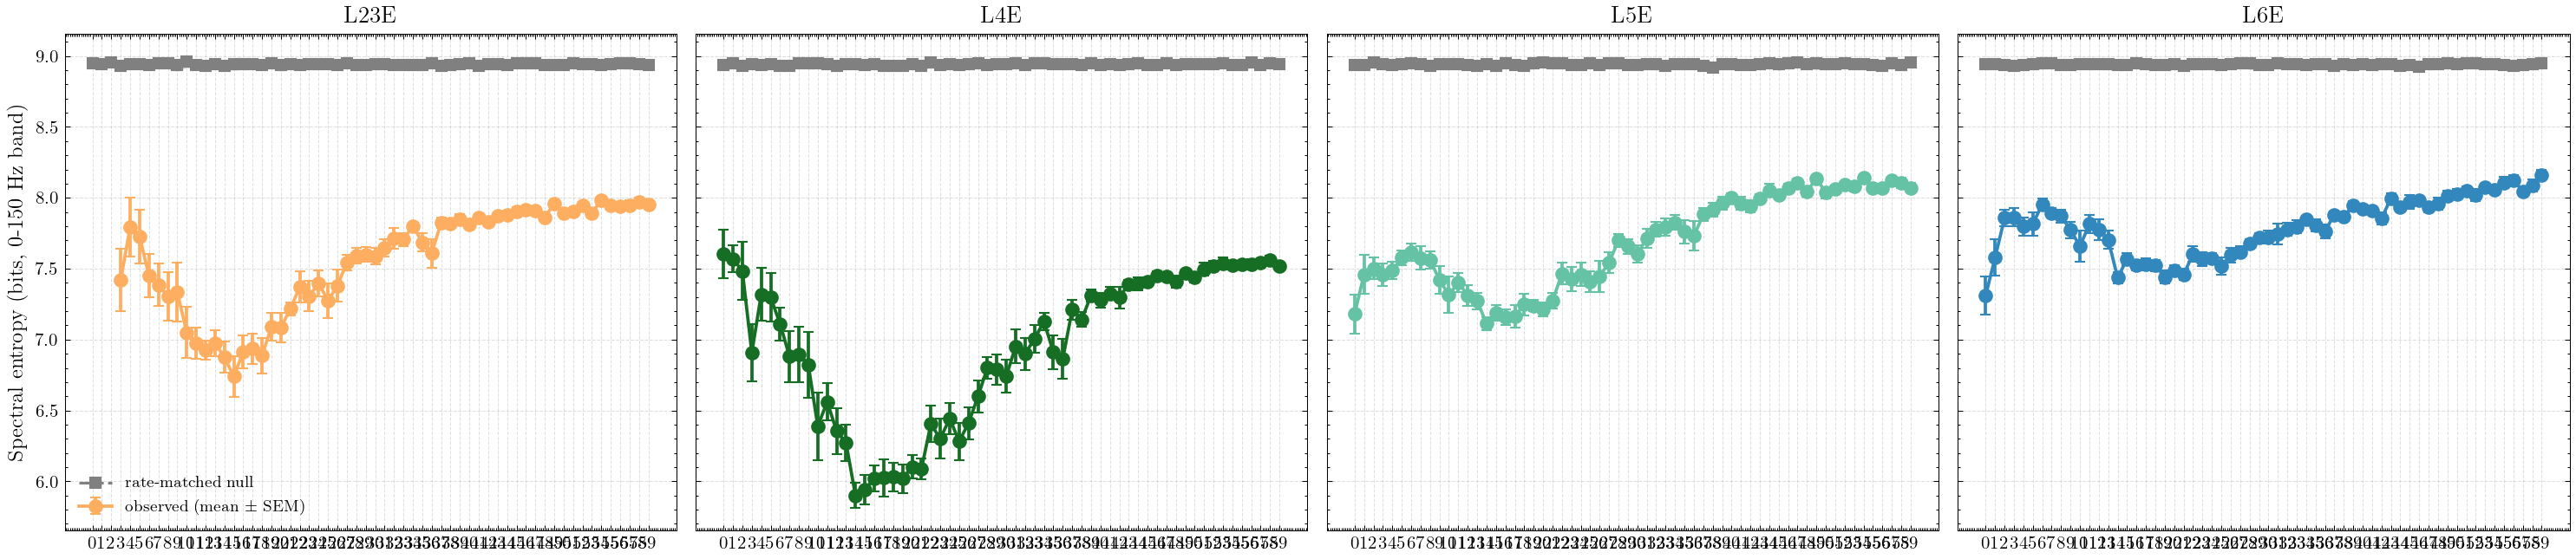

Entropy z-score, observed vs. rate-matched null (SEM+SD combined; rows=pops, cols=drives):
[[   nan    nan    nan  -6.77  -5.54  -6.35  -9.68 -10.38  -9.56  -7.56
  -10.23 -17.88 -27.5  -20.45 -18.39 -14.68 -16.87 -17.95 -16.1  -18.16
  -16.74 -32.23 -13.8  -15.21 -16.17 -13.41 -13.11 -23.65 -22.62 -22.06
  -22.23 -19.04 -15.29 -24.15 -36.   -17.16 -12.93 -23.08 -26.34 -25.21
  -31.23 -29.03 -27.52 -33.2  -23.8  -29.37 -30.77 -30.83 -32.79 -25.7
  -28.18 -32.3  -29.46 -24.34 -26.04 -26.91 -27.7  -20.92 -24.78 -28.82]
 [ -7.66 -14.23  -6.97  -9.91  -8.54  -9.52 -15.11 -11.36 -10.44  -9.05
  -10.73 -17.68 -15.75 -20.4  -33.18 -27.92 -29.76 -21.85 -28.11 -27.8
  -34.29 -37.11 -19.44 -18.44 -21.74 -19.8  -21.49 -20.43 -26.02 -19.32
  -18.5  -16.19 -17.53 -19.44 -26.94 -16.68 -14.39 -23.35 -29.83 -32.42
  -27.41 -30.96 -19.86 -41.52 -28.55 -44.11 -33.76 -40.9  -28.68 -48.15
  -33.67 -27.57 -28.46 -28.41 -40.29 -33.73 -30.86 -41.26 -37.59 -41.21]
 [-12.44 -10.74 -17.47 -17.32 -22.01 -22.81 -

In [7]:
DENSE_SWEEP_DIR = None  # e.g. "data_background_rate_fig2LtoS" -- set if available

def discover_trials(drive_dir):
    return sorted(d for d in os.listdir(drive_dir) if d.startswith("trial_"))

sweep_root = DENSE_SWEEP_DIR if (DENSE_SWEEP_DIR and os.path.isdir(DENSE_SWEEP_DIR)) \
             else "data_background_rate_big"
if DENSE_SWEEP_DIR and not os.path.isdir(DENSE_SWEEP_DIR):
    print(f"WARNING: DENSE_SWEEP_DIR='{DENSE_SWEEP_DIR}' not found -- "
          f"falling back to the 4-point sweep in '{sweep_root}'.")

dirs_sweep = sorted(os.listdir(sweep_root))
n_sweep = len(dirs_sweep)

# pop_idx_map: row p in pop_activity -> column in N_full. Default assumes the
# standard Potjans-Diesmann ordering with E populations at 0,2,4,6; edit if your
# net_dict indexes populations differently.
pop_idx_map = {0: 0, 1: 2, 2: 4, 3: 6}
N_full = network_params.net_dict["full_num_neurons"]

entropy_mean  = np.full((n_pops, n_sweep), np.nan)
entropy_sem   = np.full((n_pops, n_sweep), np.nan)
null_mean_arr = np.full((n_pops, n_sweep), np.nan)
null_std_arr  = np.full((n_pops, n_sweep), np.nan)

for i, dname in enumerate(dirs_sweep):
    drive_dir = os.path.join(sweep_root, dname)
    trial_dirs = discover_trials(drive_dir)
    if len(trial_dirs) < 2:
        print(f"WARNING: only {len(trial_dirs)} trial(s) found for '{dname}' -- "
              f"cannot estimate across-seed variability here.")

    entropy_per_trial = {p: [] for p in range(n_pops)}

    for t_idx, tname in enumerate(trial_dirs):
        base = os.path.join(drive_dir, tname, "measurements", "pop_activities")
        pop_activity_t = []
        for j in range(n_pops):
            fpath = os.path.join(base, f"pop_activity_{j*2}.dat")
            pop_activity_t.append(np.loadtxt(fpath))
        pop_activity_t = np.array(pop_activity_t)

        a, b, _ = compute_FFT(pop_activity_t, freq_sample=freq_sample)
        e = compute_spectral_entropy(a, b)   # band-limited to 150 Hz by default
        for p in range(n_pops):
            entropy_per_trial[p].append(e[p])

        # Rate-matched null from the first trial only per drive -- it's the
        # shot-noise floor implied by that drive's rate, not a per-trial quantity.
        if t_idx == 0:
            null_mean, null_std = surrogate_entropy_null(
                pop_activity_t, n_pops, N_full, pop_idx_map,
                freq_sample=freq_sample, n_surrogates=20, seed=i
            )
            for p in range(n_pops):
                null_mean_arr[p, i] = null_mean[p]
                null_std_arr[p, i]  = null_std[p]

    for p in range(n_pops):
        n = len(entropy_per_trial[p])
        entropy_mean[p, i] = np.mean(entropy_per_trial[p])
        entropy_sem[p, i]  = np.std(entropy_per_trial[p], ddof=1) / np.sqrt(n) if n > 1 else np.nan

# ── Plot observed (mean ± SEM) against the rate-matched null (mean ± SD) ────
x_sweep = np.arange(n_sweep)
#xticklabels = dirs_sweep if DENSE_SWEEP_DIR else labels_rate
xticklabels = dirs_sweep


fig, axes = plt.subplots(1, n_pops, figsize=(5 * n_pops, 4.5), dpi=150, sharey=True)
for p in range(n_pops):
    ax = axes[p]
    ax.errorbar(x_sweep, entropy_mean[p], yerr=entropy_sem[p],
                marker="o", color=colors_pops[p], linewidth=1.8,
                markersize=7, capsize=3, label="observed (mean ± SEM)")
    ax.plot(x_sweep, null_mean_arr[p], marker="s", linestyle="--", color="grey",
            linewidth=1.5, markersize=6, label="rate-matched null")
    ax.fill_between(x_sweep, null_mean_arr[p] - null_std_arr[p],
                     null_mean_arr[p] + null_std_arr[p],
                     color="grey", alpha=0.25)
    ax.set_title(pops[p], fontsize=13)
    ax.set_xticks(x_sweep)
    #ax.set_xticklabels(xticklabels, rotation=15, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
axes[0].set_ylabel("Spectral entropy (bits, 0-150 Hz band)", fontsize=12)
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── z-score of observed relative to null, propagating SEM + null SD ─────────
combined_sd = np.sqrt(entropy_sem**2 + null_std_arr**2)
z_entropy = (entropy_mean - null_mean_arr) / combined_sd
print("Entropy z-score, observed vs. rate-matched null (SEM+SD combined; rows=pops, cols=drives):")
print(np.round(z_entropy, 2))
print("Values near 0 at 6 spikes/s support reading that drive as indistinguishable")
print("from shot noise, i.e. genuinely no oscillation rather than a disordered one.")

### Combined view: all populations overlaid, one representative null

Same `entropy_mean`/`entropy_sem`/`null_mean_arr`/`null_std_arr` computed in the
cell above, just replotted as a single panel with all four populations overlaid
(matching the style of the reference figure) instead of four side-by-side
subplots. Only one null curve is drawn -- the four per-population nulls are
all close to flat and close to each other, so plotting all four would just add
clutter without adding information. `NULL_POP_IDX` picks which population's
null to show; change it if you want a different one as the reference.

In [9]:
import matplotlib as mpl

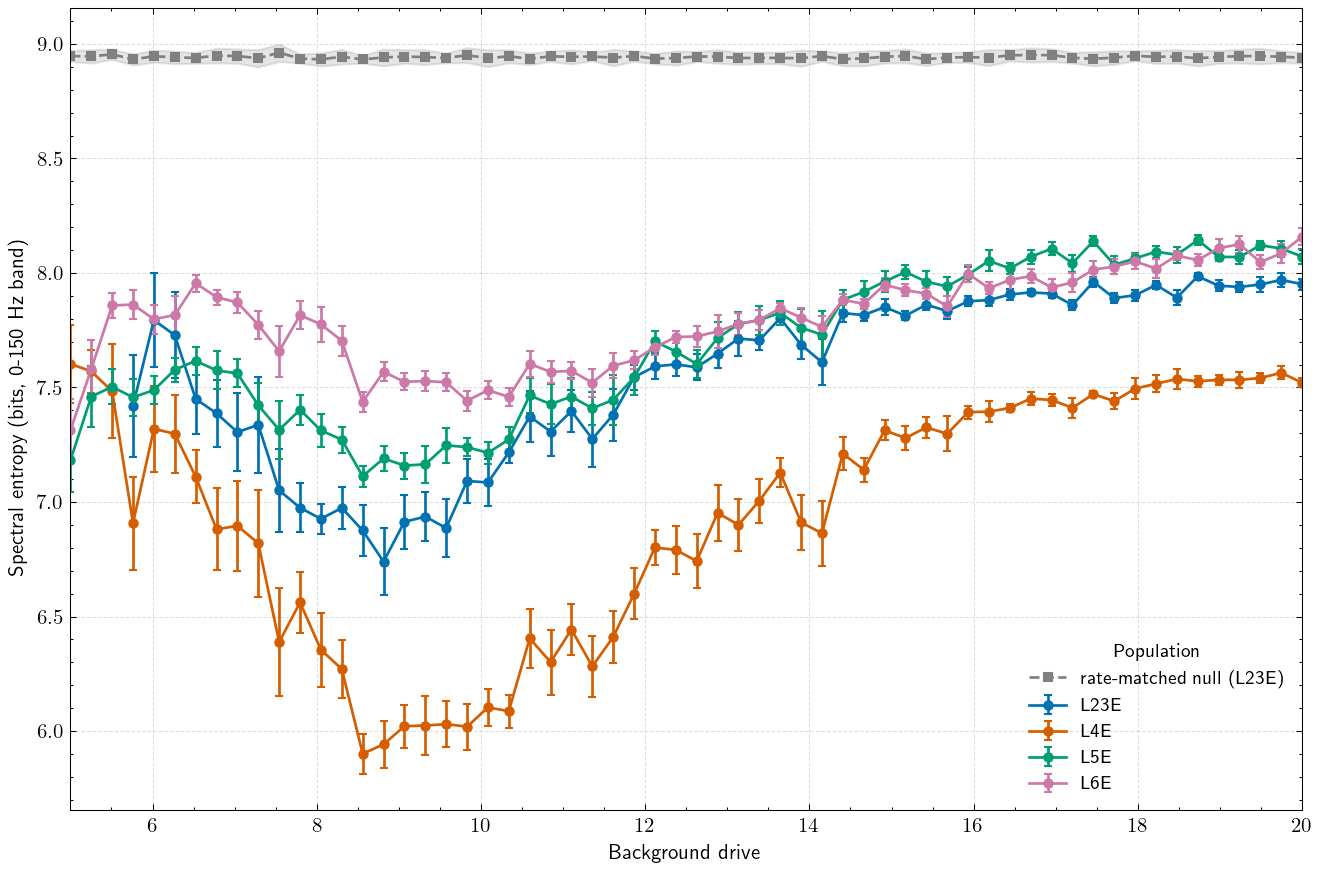

In [10]:
NULL_POP_IDX = 0  # which population's null curve to draw as the single reference (0=L23E)
mpl.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

x_plot = np.linspace(5, 20, len(x_sweep))
color_pops = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
for p in range(n_pops):
    ax.errorbar(x_plot, entropy_mean[p], yerr=entropy_sem[p],
                marker="o", markersize=4, linewidth=1.3, capsize=2,
                color=color_pops[p], label=pops[p])

ax.plot(x_plot, null_mean_arr[NULL_POP_IDX], marker="s", markersize=4,
        linestyle="--", linewidth=1.3, color="grey",
        label=f"rate-matched null ({pops[NULL_POP_IDX]})")

ax.fill_between(x_plot,
                null_mean_arr[NULL_POP_IDX] - null_std_arr[NULL_POP_IDX],
                null_mean_arr[NULL_POP_IDX] + null_std_arr[NULL_POP_IDX],
                color="grey", alpha=0.2)

ax.set_xlim(5, 20)
ax.set_xlabel("Background drive")
ax.set_ylabel("Spectral entropy (bits, 0-150 Hz band)")
ax.legend(title="Population", fontsize=9, title_fontsize=9, loc="best")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()